# Bayesian Linear Regression

Welcome to this tutorial notebook that will go through the fitting and evaluation of Normative models with Bayesian Linear Regression (BLR).

Let's jump right in.

## Imports

In [1]:
import warnings
import logging


import pandas as pd
import matplotlib.pyplot as plt
from pcntoolkit import (
    BLR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    load_fcon1000,
    plot_centiles,
    plot_centiles_advanced,
    plot_qq,
    plot_ridge,
)

import pcntoolkit.util.output
import seaborn as sns

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")

pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(True)

## Load data

First we download a small example dataset from GitHub. We use the open-source [fcon1000](https://fcon_1000.projects.nitrc.org/fcpClassic/FcpTable.html) dataset that is included in PCNtoolkit and can be loaded with one command `load_fcon1000()`.

This dataset contains derived structural MRI phenotypes from 1,078 subjects collected across 23 sites, including cortical thickness measures, subcortical and ventricular volumes, and global brain-volume estimates.

For this tutorial, we keep things simple and focus on one example brain-related measure: the `Right-Amygdala` which is the volume of the right amygdala, a deep brain structure.

In [2]:
# Download an example dataset
norm_data: NormData = load_fcon1000()

# Select only a few features
feature_to_model = [
    "Right-Amygdala",
]
norm_data = norm_data.sel({"response_vars": feature_to_model})

# Split into train and test sets
train, test = norm_data.train_test_split()

Process: 2499 - 2026-09-25 17:46:28 - Removed 0 NANs
Process: 2499 - 2026-09-25 17:46:28 - Dataset "fcon1000" created.
    - 1078 observations
    - 1078 unique subjects
    - 1 covariates
    - 217 response variables
    - 2 batch effects:
    	sex (2)
	site (23)
    


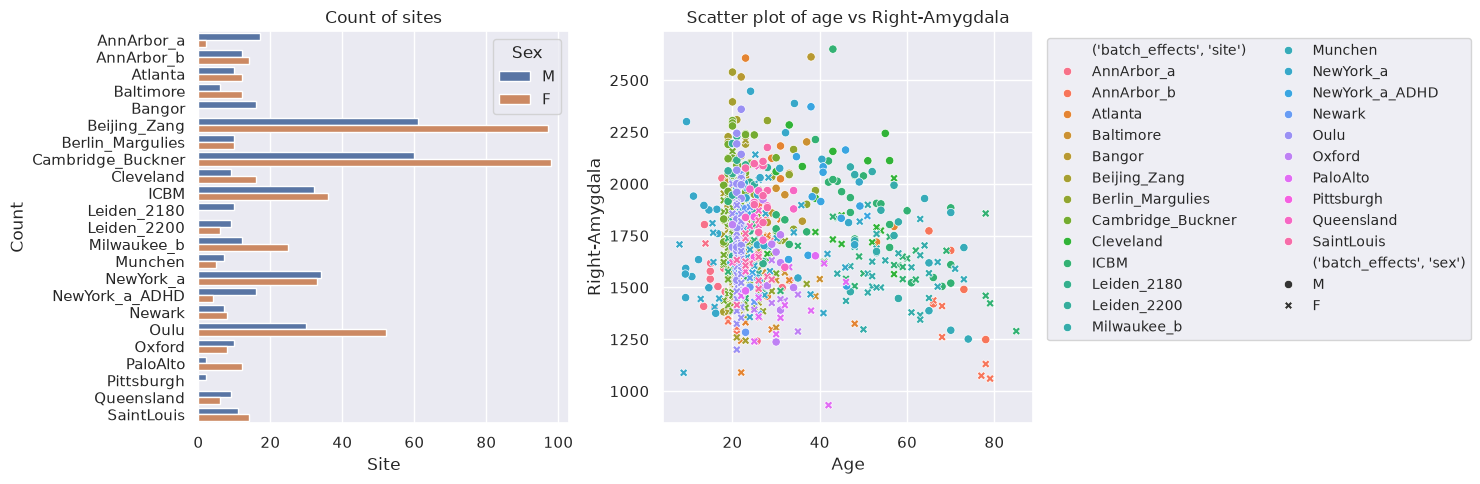

In [3]:
# Visualize the data
feature_to_plot = feature_to_model[0]
df = train.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, y=("batch_effects", "site"), hue=("batch_effects", "sex"), ax=ax[0], orient="h")
ax[0].legend(title="Sex")
ax[0].set_title("Count of sites")
ax[0].set_xlabel("Site")
ax[0].set_ylabel("Count")


sns.scatterplot(
    data=df,
    x=("X", "age"),
    y=("Y", feature_to_plot),
    hue=("batch_effects", "site"),
    style=("batch_effects", "sex"),
    ax=ax[1],
)
# Show the site/sex legend outside the plot so it does not cover the points.
ax[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small", ncol=2)
ax[1].set_title(f"Scatter plot of age vs {feature_to_plot}")
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)

plt.tight_layout()
plt.show()

The left diagram shows some sites contain more subjects than others, e.g., the biggest sites are in Beijing and Cambridge. The right diagram shows that most of the subject are between 20 and 30 years old.

## Normative model: BLR without batch effects

A normative model consists of a regression model for each response variable. Two examples of regressions models you can use with PCNtoolkit are the  Bayesian Linear Regression (BLR) and Hierarchical Bayesian Regression (HBR) models.

We start with a simple BLR model using a B-spline basis function. This model assumes Gaussian response variables and ignores batch effects (be) like site and sex.

In [4]:
blr_no_be = BLR(
    name="template",
    # We use a B-spline basis expansion for the mean, so the predicted mean is a smooth function of the covariates
    basis_function_mean=BsplineBasisFunction(degree=3, nknots=5),
    # We want the variance to be a function of the covariates
    heteroskedastic=True
)

After specifying the regression model, we can configure a normative model. 

A normative model has a number of configuration options:

- `savemodel`: Whether to save the model after fitting. It creates a JSON file
  containing your trained model parameters. This is useful to:

  - *Avoid re-fitting*: Load the saved model later instead of training from scratch every time.
  - *Share with collaborators*: Send the file to colleagues, who can update it with their own
    data, producing a better model trained on more data combined. We will cover this in the
    federated learning tutorial.

- `evaluate_model`: Whether to evaluate the model after fitting. It computes a set
   of metrics are computed that tell you how well your model fits the data. For more
   information, see our evaluation metrics tutorial.
- `saveresults`: Whether to save the per-subject results after predicting. Results include:

  - how far the observed value for this subject is from the fitted model’s predicted typical value for someone with similar covariates and batch effects (`Z`)
  - how statistically surprising the observed value for this subject is under the fitted model’s predicted distribution (`logp`).
  - fitted model’s predicted distribution at selected centiles (such as the 5th, 50th, and 95th centiles) for this subject (`centiles`)
  - summary of evaluation metrics for each response variable, when `evaluate_model` is enabled.
  
- `saveplots`: Whether to save the plots after fitting.
- `save_dir`: The directory to save the model, results, and plots.
- `inscaler`: The scaler to use for the input data. Can be either one of "standardize", "minmax", "robminmax", "none"
- `outscaler`: The scaler to use for the output data. Can be either one of "standardize", "minmax", "robminmax", "none"

In [5]:
model_blr_no_be = NormativeModel(
    template_regression_model=blr_no_be, # we select our BLR model
    savemodel=False, # we dont need to save the model for this tutorial
    evaluate_model=True, # we want to evaluate the model to see how well it fits the data
    saveresults=False, # we don't need to save the results for this tutorial
    saveplots=False,
    save_dir="resources/blr/save_dir",
    inscaler="standardize",
    outscaler="standardize",
)

### Fit the model


With all that configured, we can fit the model. 

The `fit_predict` function will fit the model, evaluate it, and save the results and plots (if so configured). 

After that, it will compute Z-scores and centiles for the test set. 

All results can be found in the save directory. 

In [6]:
model_blr_no_be.fit_predict(train, test);

Process: 2499 - 2026-09-25 17:46:29 - Fitting models on 1 response variables.
Process: 2499 - 2026-09-25 17:46:29 - Fitting model for Right-Amygdala.
Process: 2499 - 2026-09-25 17:46:29 - Making predictions on 1 response variables.
Process: 2499 - 2026-09-25 17:46:29 - Computing z-scores for 1 response variables.
Process: 2499 - 2026-09-25 17:46:29 - Computing z-scores for Right-Amygdala.
Process: 2499 - 2026-09-25 17:46:29 - Computing centiles for 1 response variables.
Process: 2499 - 2026-09-25 17:46:29 - Computing centiles for Right-Amygdala.
Process: 2499 - 2026-09-25 17:46:29 - Computing log-probabilities for 1 response variables.
Process: 2499 - 2026-09-25 17:46:29 - Computing log-probabilities for 1 response variables.
Process: 2499 - 2026-09-25 17:46:29 - Computing log-probabilities for Right-Amygdala.
Process: 2499 - 2026-09-25 17:46:29 - Computing yhat for 1 response variables.
Process: 2499 - 2026-09-25 17:46:29 - Computing yhat for Right-Amygdala.


Process: 2499 - 2026-09-25 17:46:30 - Making predictions on 1 response variables.
Process: 2499 - 2026-09-25 17:46:30 - Computing z-scores for 1 response variables.
Process: 2499 - 2026-09-25 17:46:30 - Computing z-scores for Right-Amygdala.
Process: 2499 - 2026-09-25 17:46:30 - Computing centiles for 1 response variables.
Process: 2499 - 2026-09-25 17:46:30 - Computing centiles for Right-Amygdala.
Process: 2499 - 2026-09-25 17:46:30 - Computing log-probabilities for 1 response variables.
Process: 2499 - 2026-09-25 17:46:30 - Computing log-probabilities for 1 response variables.
Process: 2499 - 2026-09-25 17:46:30 - Computing log-probabilities for Right-Amygdala.
Process: 2499 - 2026-09-25 17:46:30 - Computing yhat for 1 response variables.
Process: 2499 - 2026-09-25 17:46:30 - Computing yhat for Right-Amygdala.


Looking at the printed messages, we can identify three main steps:

1. *"Fitting models on 1 response variables."*  
   The model is being fitted on the **training data**.

2. *"Making predictions on 1 response variables."*  
   First, PCNtoolkit computes predictions on the **training data**.

3. *"Making predictions on 1 response variables."*  
   Then, PCNtoolkit computes predictions on the **test data**


### Plot the results

The PCNtoolkit offers some basic plotting functions:

1. `plot_centiles`: Plot the predicted centiles for a model
2. `plot_qq`: Plot the QQ-plot of the predicted Z-scores

Let's start with the centiles plot:

Process: 2499 - 2026-09-25 17:46:30 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site (1)
    
Process: 2499 - 2026-09-25 17:46:30 - Computing centiles for 1 response variables.
Process: 2499 - 2026-09-25 17:46:30 - Computing centiles for Right-Amygdala.
Process: 2499 - 2026-09-25 17:46:30 - Harmonizing data on 1 response variables.
Process: 2499 - 2026-09-25 17:46:30 - Harmonizing data for Right-Amygdala.


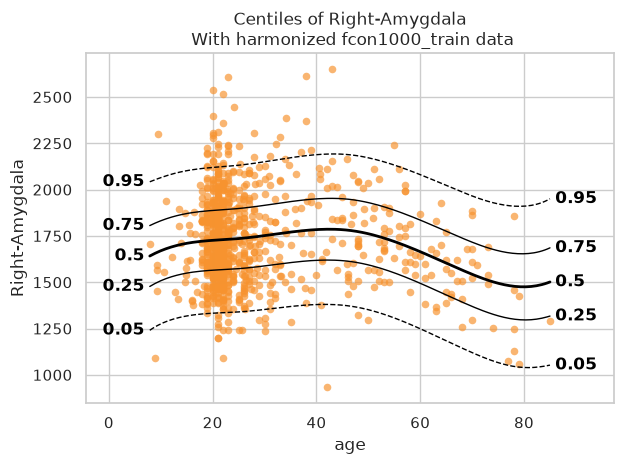

In [7]:
plot_centiles(model_blr_no_be, scatter_data=train);

Now let's see the qq plots

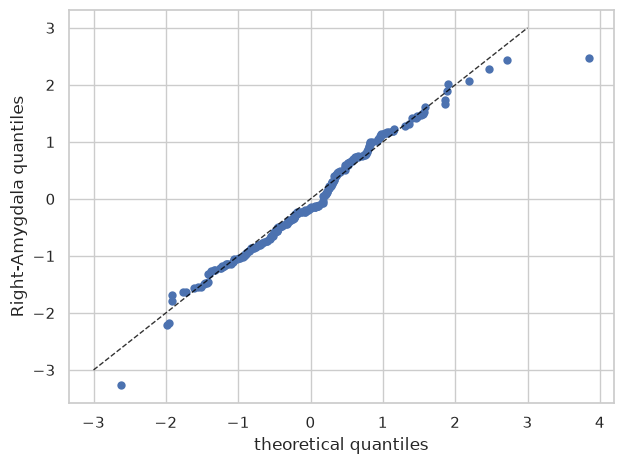

In [8]:
plot_qq(test, plot_id_line=True);

### Evaluation statistics
Evaluation statistcs are stored in the `NormData` object. There is a separate tutorial for detailed explanations of each metric.

In [9]:
# Show the evaluation metrics from the train set
display(train.get_statistics_df())
# Show the evaluation metrics from the train set
display(test.get_statistics_df())

statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
Right-Amygdala,0.048814,0.362042,0.164147,0.113045,1.394435,-0.024504,0.048811,238.945545,0.103927,0.00225,0.951189,0.989094,0.395298


statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
Right-Amygdala,0.02428,-0.114357,0.192422,0.115754,1.371371,-0.009898,0.023483,233.155609,0.062144,0.363402,0.976517,0.992001,0.052936


## Normative model: warped-BLR without batch effects
Now we fit a more flexible warped-BLR model.The warp lets the model handle response distributions that are non-Gaussian, for example when the data are skewed or have heavier tails. We again ignore the batch effects (be).

Find more information about the warped-BLR (w-BLR) on this paper:
> Fraza, C. J., Dinga, R., Beckmann, C. F., & Marquand, A. F. (2021). Warped Bayesian linear regression for normative modelling of big data. NeuroImage, 245, 118715. https://doi.org/10.1016/j.neuroimage.2021.118715

In [10]:
# To reduce tutorial clutter, we suppress the internal "Process: ..." messages. 
# For your own analyses, we recommend keeping them enabled to better understand 
# what is happening and to help us troubleshoot any issues you report.
pcntoolkit.util.output.Output.set_show_messages(False)

In [11]:
wblr_no_be = BLR(
    name="template",
    # We use a B-spline basis expansion for the mean, so the predicted mean is a smooth function of the covariates
    basis_function_mean=BsplineBasisFunction(degree=3, nknots=5),
    # We want the variance to be a function of the covariates
    heteroskedastic=True,
    
    # Allow warping
    warp_name="warpsinharcsinh",  # We configure a sinh-arcsinh warp
)

In [12]:
model_wblr_no_be = NormativeModel(
    template_regression_model=wblr_no_be, # we select our w-BLR model
    savemodel=False, # we dont need to save the model for this tutorial
    evaluate_model=True, # we want to evaluate the model to see how well it fits the data
    saveresults=False, # we don't need to save the results for this tutorial
    saveplots=False,
    save_dir="resources/blr/save_dir",
    inscaler="standardize",
    outscaler="standardize",
)

### Fit the model

In [13]:
model_wblr_no_be.fit_predict(train, test);

### Plot the results


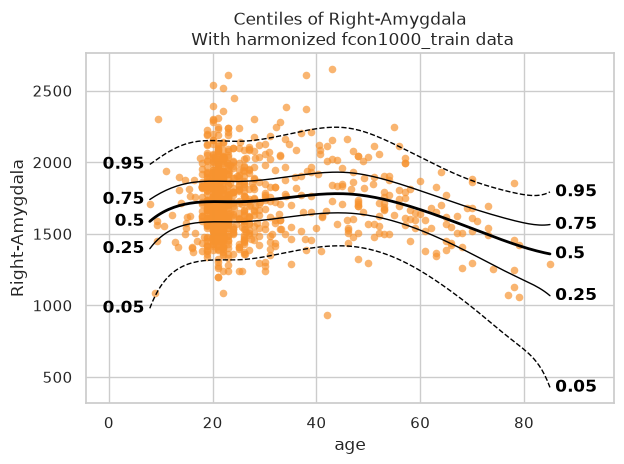

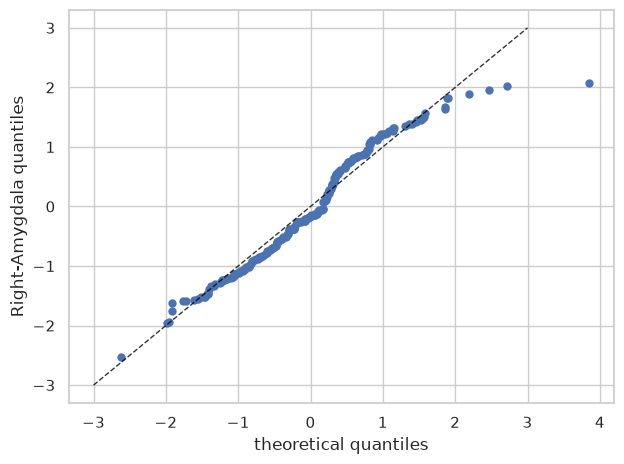

statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
Right-Amygdala,0.05366,-0.707014,0.164279,0.112218,1.413484,-0.005455,0.053443,238.363006,0.12808,0.000163,0.946557,0.984873,0.184109


statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
Right-Amygdala,0.02234,-0.891817,0.196683,0.115131,1.41166,0.03039,0.022092,233.321625,0.044472,0.515609,0.977908,0.978714,0.046409


In [14]:
# centile plots
plot_centiles(model_wblr_no_be, scatter_data=train);

# qq-plots
plot_qq(test, plot_id_line=True);

# Show the evaluation metrics from the train set
display(train.get_statistics_df())
# Show the evaluation metrics from the train set
display(test.get_statistics_df())

## Normative model: warped-BLR with batch effects
Now we keep the same warped-BLR model but we also model the batch effects (be). Here, the batches are variables such as site and sex. Adding batch effects lets the model account for systematic differences between groups, instead of forcing all groups to follow exactly the same mean and variance patterns.

In [15]:
wblr_with_be = BLR(
    name="template",
    # We use a B-spline basis expansion for the mean, so the predicted mean is a smooth function of the covariates
    basis_function_mean=BsplineBasisFunction(degree=3, nknots=5),
    # We want the variance to be a function of the covariates
    heteroskedastic=True,
    
    # Allow warping
    warp_name="warpsinharcsinh",  # We configure a sinh-arcsinh warp

    # Model the batch effects (sex and site)
    fixed_effect=True,  # We model offsets in the mean for each individual batch effect
    fixed_effect_slope=True,  # We model a fixed effect in the slope of the mean for each individual batch effect
    fixed_effect_var_slope=True, # We model a fixed effect in the slope of the variance for each individual batch effect
)

In [16]:
model_wblr_with_be = NormativeModel(
    template_regression_model=wblr_with_be, # we select our w-BLR model
    savemodel=False, # we dont need to save the model for this tutorial
    evaluate_model=True, # we want to evaluate the model to see how well it fits the data
    saveresults=False, # we don't need to save the results for this tutorial
    saveplots=False,
    save_dir="resources/blr/save_dir",
    inscaler="standardize",
    outscaler="standardize",
)

### Fit the model

In [17]:
model_wblr_with_be.fit_predict(train, test);

/home/runner/work/PCNtoolkit/PCNtoolkit/pcntoolkit/regression_model/blr.py:640: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.8749209772067033e-46.
  invAXt: np.ndarray = linalg.solve(self.A, X.T, check_finite=False)
/home/runner/work/PCNtoolkit/PCNtoolkit/pcntoolkit/util/output.py:309: UserWarning: Process: 2499 - 2026-09-25 17:46:51 - Posterior estimation failed: 
Matrix is not positive definite. 
The optimizer could not find a stable solution. Retrying optimization.
  warnings.warn(message, category)
/home/runner/work/PCNtoolkit/PCNtoolkit/pcntoolkit/regression_model/blr.py:640: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.176897254651122e-45.
  invAXt: np.ndarray = linalg.solve(self.A, X.T, check_finite=False)
/home/runner/work/PCNtoolkit/PCNtoolkit/pcntoolkit/regression_model/blr.py:640: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.479209053968284e-41.
  invAXt: np.ndarray = linalg.solve(self.A, X.T

/home/runner/work/PCNtoolkit/PCNtoolkit/pcntoolkit/regression_model/blr.py:640: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.8749209772067045e-46.
  invAXt: np.ndarray = linalg.solve(self.A, X.T, check_finite=False)
/home/runner/work/PCNtoolkit/PCNtoolkit/pcntoolkit/regression_model/blr.py:640: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.8752012455748466e-46.
  invAXt: np.ndarray = linalg.solve(self.A, X.T, check_finite=False)
/home/runner/work/PCNtoolkit/PCNtoolkit/pcntoolkit/regression_model/blr.py:640: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1788065231769523e-45.
  invAXt: np.ndarray = linalg.solve(self.A, X.T, check_finite=False)


### Plot the results

Because this model includes batch effects, we can now visualize results not only over all data, but also separately for specific groups such as sites or sexes.

Below we show a few useful options: `plot_centiles_advanced` to highlight specific batch effects in the plot, `plot_qq` to inspect model fit by batch effects, and `plot_ridge` to compare the distribution of responses or Z-scores across batch effects.

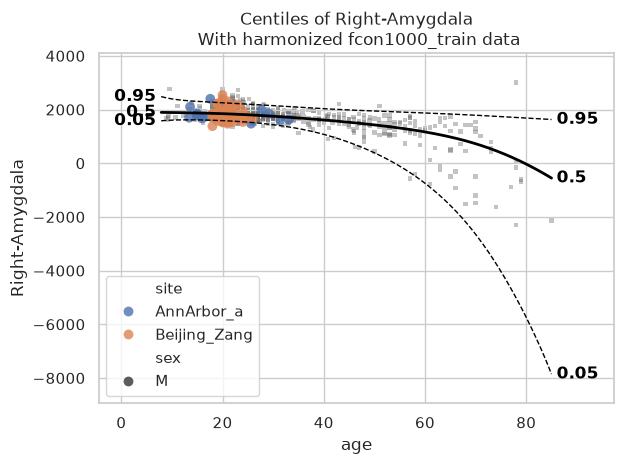

In [18]:
plot_centiles_advanced(
    model_wblr_with_be,
    scatter_data=train,

    # Plot these centiles, the default is [0.05, 0.25, 0.5, 0.75, 0.95]
    centiles=[0.05, 0.5, 0.95],  
    
    # Highlight a specific gender from specific sites
    batch_effects={"site": [ "Beijing_Zang", "AnnArbor_a",], "sex": ["M"]},
    # Show other data not belonging to the groups above
    show_other_data=True,
    
    # Harmonize the scatterdata, this means that we 'remove' the batch effects from the data, by simulating what the data would have looked like if all data was from the same batch.
    harmonize_data=True
);

When we call `plot_centiles_advanced`, the function prints messages such as *Computing centiles* and *Harmonizing data for Right-Amygdala*. These messages appear because the plot also computes centiles and harmonize the data for *based on the batch effects* that you selected in the function call (see `batch_effects` keyword argument).

> **Exercise**
> Set `batch_effects='all'` in `plot_centiles_advanced`. How does that affect your plotted centiles and scatter data?

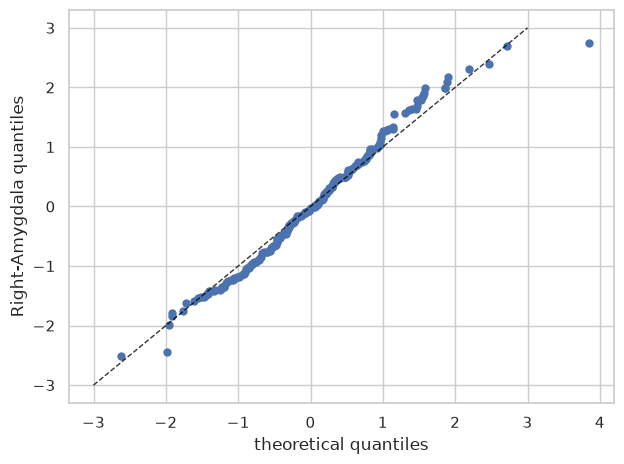

statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
Right-Amygdala,0.396814,-0.234987,0.093566,0.086449,1.173224,-0.245715,0.396811,190.27961,0.611902,1.115659e-89,0.603189,0.997733,0.115495


statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
Right-Amygdala,0.285102,-0.337598,0.143504,0.094148,1.244851,-0.136419,0.284633,199.55859,0.511902,7.958027e-16,0.715367,0.98873,0.189983


In [19]:
# qq-plot
plot_qq(test, plot_id_line=True);

# Show the evaluation metrics from the train set
display(train.get_statistics_df())
# Show the evaluation metrics from the train set
display(test.get_statistics_df())

### QQ-plot and ridge plot per batch effect

Finally, we show how we can use `plot_qq` and `plot_ridge` split based on the batch effects (here we choose to split based on males and females):

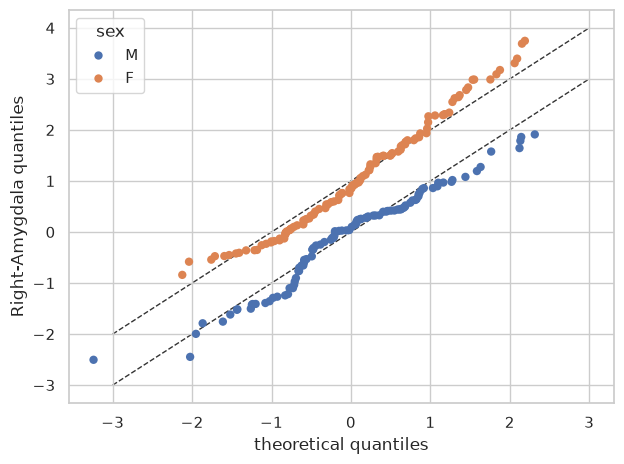

In [20]:
# Show the qq-plot per sex
plot_qq(test, plot_id_line=True, hue_data="sex", split_data="sex")
sns.set_theme(style="darkgrid", rc={"axes.facecolor": (0, 0, 0, 0)})

/opt/hostedtoolcache/Python/3.13.15/x64/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/hostedtoolcache/Python/3.13.15/x64/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/hostedtoolcache/Python/3.13.15/x64/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/hostedtoolcache/Python/3.13.15/x64/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to acco

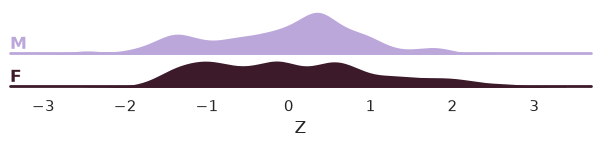

/opt/hostedtoolcache/Python/3.13.15/x64/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/hostedtoolcache/Python/3.13.15/x64/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/hostedtoolcache/Python/3.13.15/x64/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/hostedtoolcache/Python/3.13.15/x64/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to acco

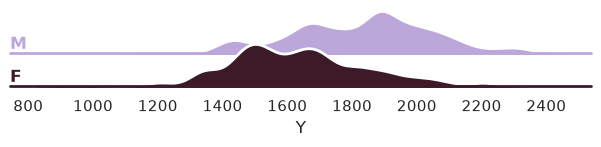

In [21]:
# Show the ridge plot per sex
plot_ridge(test, "Z", split_by="sex");

# We can also show the 'Y' variable
plot_ridge(test, "Y", split_by="sex");

## Compare the three models

BLR (no be)


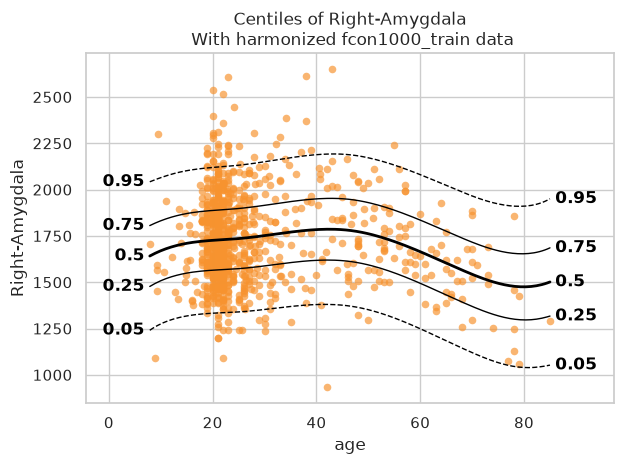

w-BLR (no be)


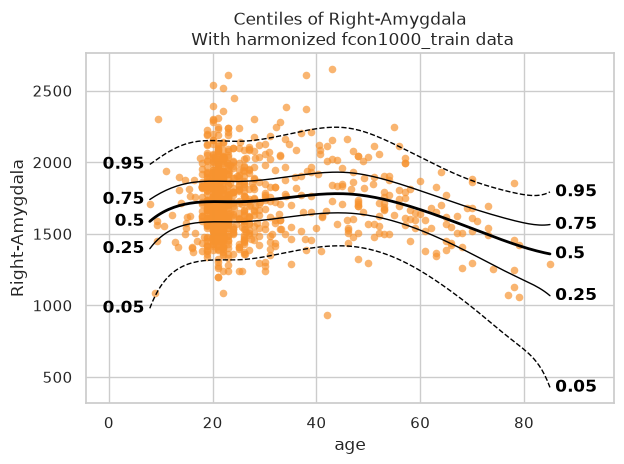

w-BLR (with be)


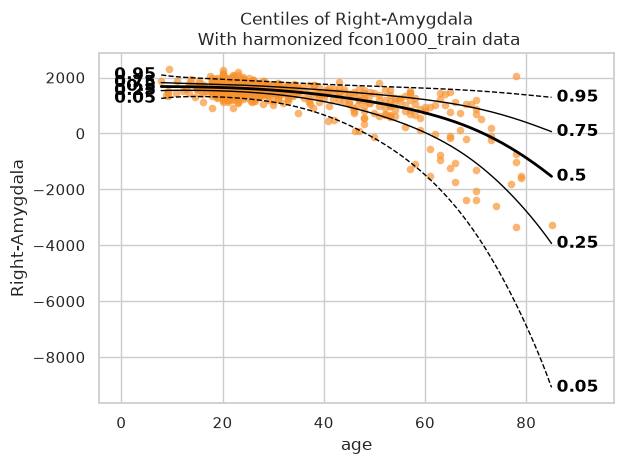

In [22]:
models = {
    "BLR (no be)": model_blr_no_be,
    "w-BLR (no be)": model_wblr_no_be,
    "w-BLR (with be)": model_wblr_with_be,
}

# Plot the centiles of each model to compare
for model_name, m in models.items():
    print(model_name)
    plot_centiles(m, scatter_data=train);


The 0.05 centile and even the 0.5 centile of the 3rd model (w-BLR with batch effects) can become negative, even though the response variable here, Right-Amygdala, is a volume and therefore should remain positive. So, modelling each batch effect (site) seems to not improve the model. A likely reason is that the dataset is very heterogeneous: uneven site sizes, several small sites, and sites that cover different, sometimes narrow age ranges (see the cell in the beginning of this notebook where we visualise the data).

This is a useful reminder that a more flexible model is not always a better model. To model the approximately Gaussian distributed Right Amygdala volume, the simpler BLR without batch effects model (1st model) seems to be the best choice. It is important to always *understand your data* before you select a model.

## What's next?

Now we have a normative BLR model, we can use it to:

- Harmonize data
- Synthesize new data

### Harmonize

In PCNtoolkit, harmonization happens after we fit a model. For each subject, it uses the fitted model to predict what their measured value (Y) would be if they came from a single reference group (e.g., a specific site and sex). A big advantage of this method is that its transformation is invertible so you can always go back to your original Y values.

Let's first harmonize to the Beijing_Zang which has subjects ages 18-26:

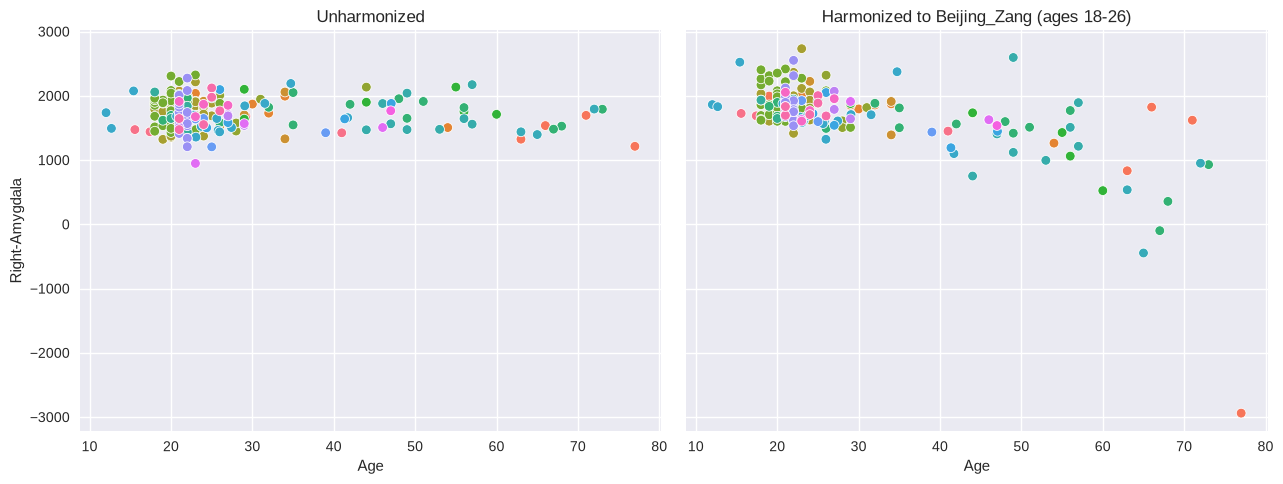

In [23]:
# Select the reference group: Beijing_Zang is one of the largest sites
# (198 subjects) but they are all aged 18-26.
reference_batch_effect = {
    "site": "Beijing_Zang",
    "sex": "M",
}

# Harmonize
model_wblr_with_be.harmonize(test, reference_batch_effect=reference_batch_effect)

plt.style.use("seaborn-v0_8")
df = test.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
sns.scatterplot(data=df, x=("X", "age"), y=("Y", feature_to_plot), hue=("batch_effects", "site"), ax=ax[0])
sns.scatterplot(data=df, x=("X", "age"), y=("Y_harmonized", feature_to_plot), hue=("batch_effects", "site"), ax=ax[1])
ax[0].title.set_text("Unharmonized")
ax[1].title.set_text("Harmonized to Beijing_Zang (ages 18-26)")
ax[0].legend([], [])
ax[1].legend([], [])
ax[0].set_xlabel("Age")
ax[0].set_ylabel(feature_to_plot)
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)
plt.tight_layout()
plt.show()

Notice that the oldest subjects get **negative** volumes after harmonizing. The reference group is a *choice*, so let's harmonize the same data again, this time to `ICBM`, which covers the full age range (19-85):

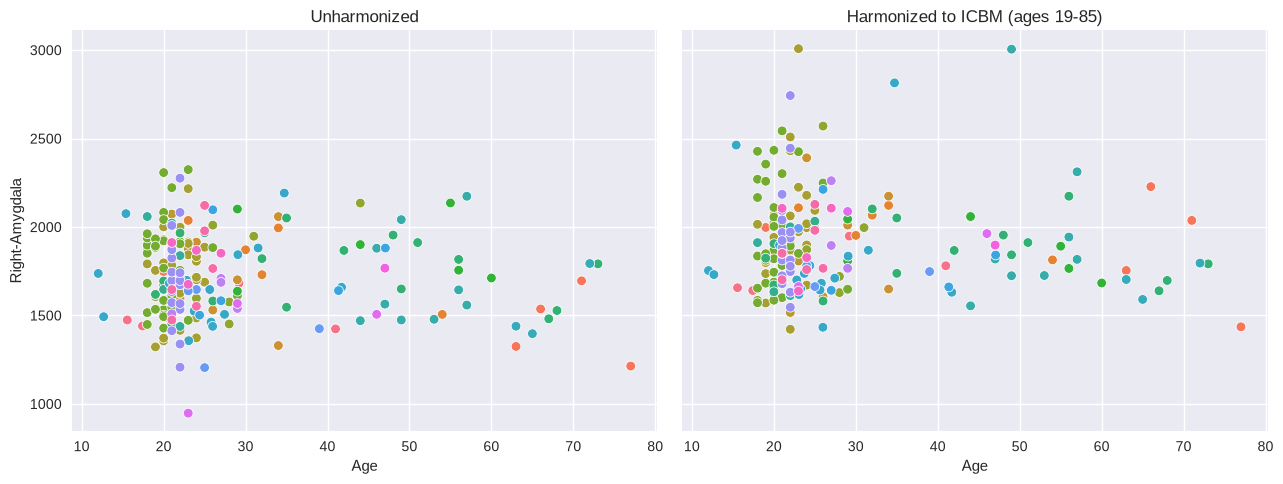

In [24]:
# Now harmonize the same data to ICBM instead: a smaller site (85
# subjects) but it spans the full age range (19-85).
reference_batch_effect = {
    "site": "ICBM",
    "sex": "M",
}

# Harmonize
model_wblr_with_be.harmonize(test, reference_batch_effect=reference_batch_effect)

plt.style.use("seaborn-v0_8")
df = test.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
sns.scatterplot(data=df, x=("X", "age"), y=("Y", feature_to_plot), hue=("batch_effects", "site"), ax=ax[0])
sns.scatterplot(data=df, x=("X", "age"), y=("Y_harmonized", feature_to_plot), hue=("batch_effects", "site"), ax=ax[1])
ax[0].title.set_text("Unharmonized")
ax[1].title.set_text("Harmonized to ICBM (ages 19-85)")
ax[0].legend([], [])
ax[1].legend([], [])
ax[0].set_xlabel("Age")
ax[0].set_ylabel(feature_to_plot)
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)
plt.tight_layout()
plt.show()

When harmonizing to ICBM no subjects get negative volumes. 

*So why with the Beijing_Zang we got negative volumes while with the ICBM not?*

Ans. To harmonize an old subject, the model has to guess what Beijing_Zang looks like at age 70. But Beijing_Zang only has people up to 26, so it has to extrapolate for older ages. In contrast, ICBM has older people, so it does not extrapolate and its values can remain within the accepted positive range.

> **Exercise**: We used the 3rd model - the one *with modeled batch effects* - for harmonization. Why do you think that is? And what would happen if you used a model *without batch effects* (the 1st or 2nd)?

### Synthesize

Our models can synthesize new data that follows the learned distribution. 

Not only the distribution of the response variables given a covariate is learned, but also the ranges of the covariates _within_ each batch effect. So if we have fitted a model on a number of sites, and subjects from A have an age between 10 and 20, then the synthesized pseudo-subjects from site A will also have an age between 10 and 20.

Not only that, but we also sample the batch effects in the frequency of the batch effects in the original data. So if the train data contained twice as many subjects from site A as site B, then the synthesized pseudo-subjects will also have twice as many subjects from site A as site B.

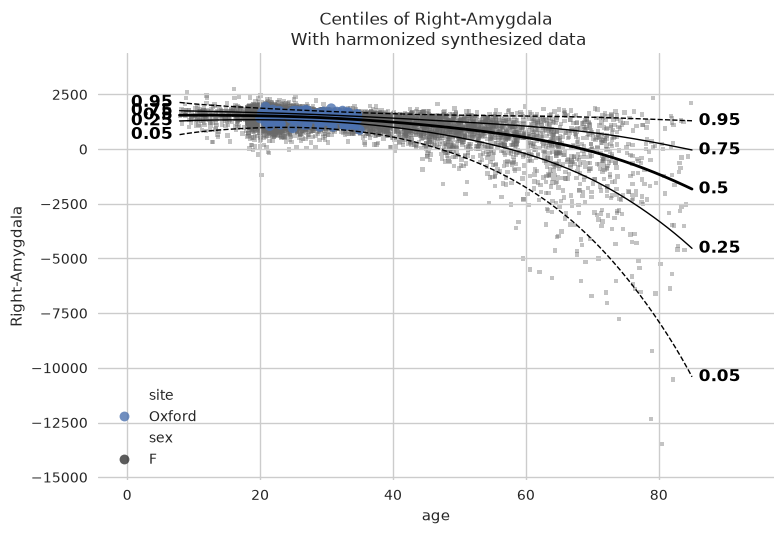

In [25]:
# Generate 10000 synthetic datapoints from scratch
synthetic_data = model_wblr_with_be.synthesize(covariate_range_per_batch_effect=True, n_samples=10000)  # <- also easy
plot_centiles_advanced(
    model_wblr_with_be,
    covariate="age",  # Which covariate to plot on the x-axis
    scatter_data=synthetic_data,
    show_other_data=True,
    harmonize_data=True,
    show_legend=True,
);

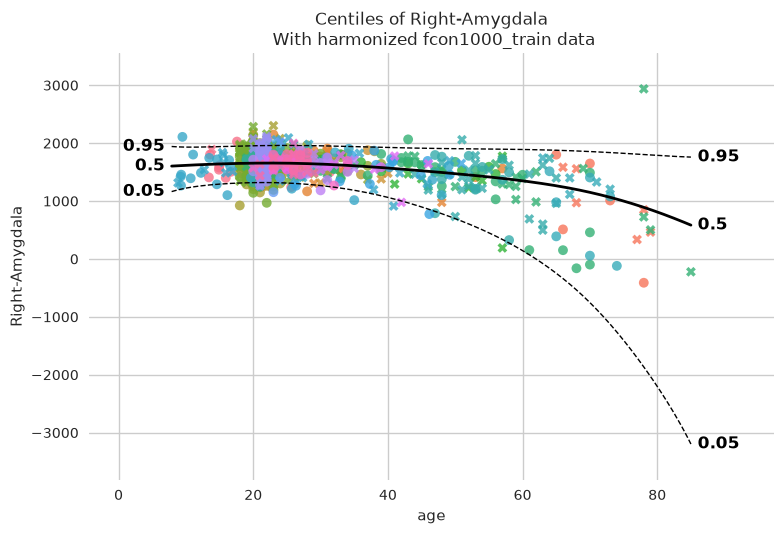

In [26]:
# Synthesize new Y data for existing X data
new_test_data = test.copy()

# Remove the Y data, this way we will synthesize new Y data for the existing X data
if hasattr(new_test_data, "Y"):
    del new_test_data["Y"]

synthetic = model_wblr_with_be.synthesize(new_test_data)  # <- will fill in the missing Y data
plot_centiles_advanced(
    model_wblr_with_be,
    centiles=[0.05, 0.5, 0.95],  # Plot arbitrary centiles
    covariate="age",  # Which covariate to plot on the x-axis
    scatter_data=train,  # Scatter the train data points
    batch_effects="all",  # You can set this to "all" to show all batch effects
    show_other_data=True,  # Show data points that do not match any batch effects
    harmonize_data=True,  # Set this to False to see the difference
    show_legend=False,  # Don't show the legend because it crowds the plot
);